# Hall effect analysis

Use this template as a starting point to carry out the analysis tasks.  For reference, here are links to recommended Python resources: the [Whirlwind Tour of Python](https://jakevdp.github.io/WhirlwindTourOfPython/) and the [Python Data Science Handbook](https://jakevdp.github.io/PythonDataScienceHandbook/) both by Jake VanderPlas.

## Standard Packages

This is a good idea at the beginning of your notebook to include the packages that you will need.  We will use those shown below here.  A brief description:
* `numpy` is the foundational package for Python numerical work. It extends and speeds up array operations beyond standard Python, and it includes almost all math functions that you would need for example `sqrt()` (square root) or `cos()` (cosine).  These would be written in code as `np.sqrt()` or `np.cos()`.
* `scipy` is a huge collection of scientific data analysis functions, routines, physicical constants, etc.  This is the second most used package for scientific work. Here we will use the physical constants library, `scipy.constants`.  Documentation is at [SciPy.org](https://docs.scipy.org/doc/scipy/reference/) with the constants subpackage at https://docs.scipy.org/doc/scipy/reference/constants.html.
* `uncertainties` is a very useful small package that simplifies uncertainty propagation and printing out of quantities with uncertainty. Documentation is at https://pythonhosted.org/uncertainties/
* `matplotlib` is *the* standard plotting package for scientific Python.  We will use a subset called `pyplot` which is modeled after the plotting functions used in MATLAB. The last line below, `%matplotlib inline`, simply forces the plots to appear within the notebook.
* `pandas` is a large data science package.  It's main feature is a set of methods to create and manipulate a "DataFrame," which is an enlargement of the idea of an array.  I plays well with NumPy and other packages.  We will use it mainly as a way to read files into data sets in an easy way.
* [LMFit](https://lmfit.github.io/lmfit-py/) is excellent for carrying out line and curve fits with many useful features.

## Getting Help

See the example code for a wide range of actions in notebooks created by Prof. Marjorie Olmstead and Prof. David Pengra in this repository: [**Physics431/Examples**](https://github.com/Physics431/Examples).

You can pull the examples into your environment with the following command.  (Only do this once, or you will get an error):

    git clone https://github.com/Physics431/Examples

## Task Summary

1. If not already done, enter the raw data into a spreadsheet, save the file(s) and make them available to the members of the group.  You should have at least 4 different tables: measurements for each probe plus the measurements of the magnetic field
2. Import the magnetic field measurements.  Calculate a mean and standard deviation for the magnetic field $B$ at the location of the probes between the poles.
3. Import the measurements from each probe. Calculate $2V_H$ for each value of $I_x$  for each probe, as described in the instructions.  Show a code snippet that does this or describe the calculation in your group notebook with an example.
4. Plot $2V_H$ versus $I_x$  for each sample and fit a line to it using LMfit.  Obtain the fit coefficients and their uncertainty.
5. Calculate the Hall coefficient $R_H$ for each probe and propagate the uncertainty from the fit, uncertainty in the magnetic field, and uncertainties in the probe specifications given in Table 1 in the instructions.
6. Determine the source of the largest statistical uncertainty, and explain how this was determined. 
7. Calculate the conductivity of the sample material and its uncertainty for all three samples.
8. Calculate the Hall mobility $\mu$ for the InAs probe.  (You can also calculate a mobility for the metal probes, but its meaning is suspect.)

In [29]:
# Usually import packages via a handle to the functions in them using import ... as ...
#
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import uncertainties as unc
from uncertainties import ufloat
from uncertainties import unumpy as unp
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning) # Removing annoying warnings after code is ran
%matplotlib inline

In [30]:
# Useful plot default
mpl.rcParams['figure.figsize'] = 12.0,8.0  # Roughly 12 cm wde by 8 cm high
mpl.rcParams['font.size'] = 14.0 # Use 14 point font

## Read in the B-field data

If the data files are spreadsheet files with comma-separated values (CSV) they can be read in with Pandas `pd.read_csv()`:
    
    B_data = pd.read_csv('Hall_magnet_measurements.csv')


In [31]:
# You code this

# Reading in the Bfield
B_data = pd.read_csv('HE_Bfield_Clean.csv')/10 # Dividing by 10 because 10 kG is 1 T
B_data

,Center (0),Top (+z),Bottom (-z),Front (+y),Back(-y),Right(+x),Left(-x)
0,-0.13347,-0.12833,-0.13178,-0.13369,-0.13756,-0.13398,-0.13395
1,0.13323,0.13520,0.13230,0.13502,0.13276,0.13330,0.13397


Calculate the average value of the field and its standard deviation, correcting for the sign reversal.  One way to do this is to create a new NumPy array that holds all values as absolute-values, and then use the methods within the array.  

In [32]:
# You code this

# Calculating average value and standard deviation of B field

# Defining columns with B-field measurements
measurement_columns = ['Center (0)', 'Top (+z)', 'Bottom (-z)', 'Front (+y)', 'Back(-y)', 'Right(+x)', 'Left(-x)']

B_matrix = B_data[measurement_columns].values # Grabbing columns and converting to a combined NumPy array, Flattening to raw array of numbers

B_values_abs = np.abs(B_matrix) # Correcting for the sign reversals across all data points

# Calculating the mean and standard deviation
B = np.mean(B_values_abs) 
sigma_B = np.std(B_values_abs, ddof=1)

In [33]:
# Create an uncertainty object that holds the field and its uncertainty.

# You need the values of B and its uncertainty 
uB = unc.ufloat(B,sigma_B,'B') # the extra label is a "tag" that can be used with some of the Uncertainties functions
print('The field strength of the magnet = {:.4uP} T'.format(uB))

The field strength of the magnet = 0.133467±0.002041 T


## Read in the probe data

As before, use `pd.read_csv()`.

Then for each, create an array that gives $2V_H$, twice the hall voltage.  Be careful with signs! 

In [34]:
# Start with aluminum probe data
# You code this

probe_data = pd.read_csv('Hall_effect_Clean.csv', header=None)

# Reading in aluminum probe uncertainties 
probe_data_err = pd.read_csv('Hall_effect_Uncertainty_Clean.csv', header=None)

In [35]:
# Extracting rows 1 and 2 and skipping the first 0 column
v_orient1 = pd.to_numeric(probe_data.iloc[1, 1:], errors='coerce').values
v_orient2 = pd.to_numeric(probe_data.iloc[2, 1:], errors='coerce').values

# Extracting corresponding uncertainties 
v_err1 = pd.to_numeric(probe_data_err.iloc[1, 1:], errors='coerce').values if isinstance(probe_data_err, pd.DataFrame) else probe_data_err
v_err2 = pd.to_numeric(probe_data_err.iloc[2, 1:], errors='coerce').values if isinstance(probe_data_err, pd.DataFrame) else probe_data_err

# Calculate 2VH
# Recommended: add it as a column in the existing dataframe.

# Function computing 2VH and associating its uncertainty with each value
def calculate_u_2VH(v1, v2, err1, err2, start_idx, end_idx):
    # Slicing values
    slice_v1 = v1[start_idx:end_idx]
    slice_v2 = v2[start_idx:end_idx]
    
    # Slicing/Defining errors
    slice_err1 = err1[start_idx:end_idx] if isinstance(err1, np.ndarray) else err1
    slice_err2 = err2[start_idx:end_idx] if isinstance(err2, np.ndarray) else err2
    
    # Creating arrays
    uv1 = unp.uarray(slice_v1, slice_err1)
    uv2 = unp.uarray(slice_v2, slice_err2)
    
    # Calculating 2VH
    return np.abs(uv1 - uv2)

# Defining aluminum columns
current_al_raw = np.array([0, 20, 40, 60, 80, 100, 120, 140, 160, 180])
u_twoV_H_al_raw = calculate_u_2VH(v_orient1, v_orient2, v_err1, v_err2, 10, 20)

# Excluding 100 mA outlier using a boolean mask
mask = (current_al_raw != 100)
current_al = current_al_raw[mask]
u_twoV_H_al = u_twoV_H_al_raw[mask]

In [36]:
# Repeat for gold probe data

# Defining gold columns
current_au = np.array([0, 20, 40, 60, 80, 100, 120, 140, 160, 180])
u_twoV_H_au = calculate_u_2VH(v_orient1, v_orient2, v_err1, v_err2, 20, 30)

In [37]:
# Repeat for InAs probe data

# Defining InAs columns
current_inas = np.array([0, 10, 20, 30, 40, 50, 60, 70, 80, 90])
u_twoV_H_inas = calculate_u_2VH(v_orient1, v_orient2, v_err1, v_err2, 0, 10)

## Make a couple of plots

The metal probes typically have similar Hall voltages. You should plot them on the same graph to compare, but InAs has much higher values and would need its own plot.

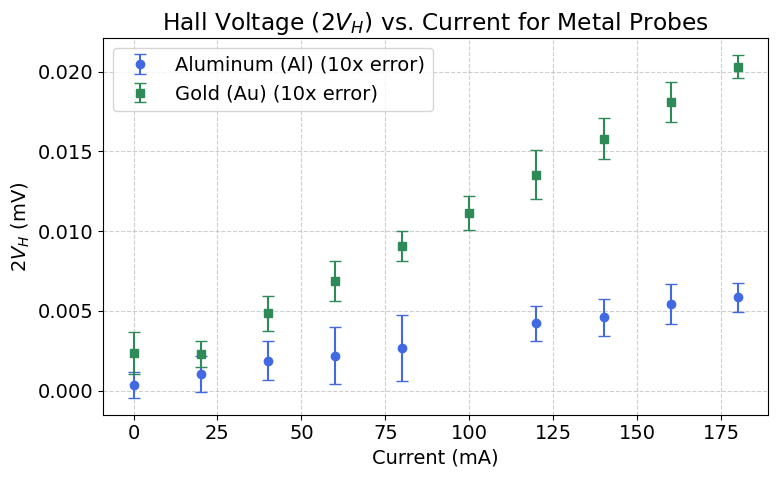

In [38]:
# Extracting the nominal values and standard deviation

al_y = unp.nominal_values(u_twoV_H_al)
al_yerr = unp.std_devs(u_twoV_H_al)

au_y = unp.nominal_values(u_twoV_H_au)
au_yerr = unp.std_devs(u_twoV_H_au)

inas_y = unp.nominal_values(u_twoV_H_inas)
inas_yerr = unp.std_devs(u_twoV_H_inas)


# See the examples for how to make a plot
# Metal probes first.

SCALE_FACTOR = 10

plt.figure(figsize=(8, 5))
plt.errorbar(current_al, al_y, yerr=al_yerr * SCALE_FACTOR, fmt='o', capsize=4, label=f'Aluminum (Al) ({SCALE_FACTOR}x error)', color='royalblue')
plt.errorbar(current_au, au_y, yerr=au_yerr * SCALE_FACTOR, fmt='s', capsize=4, label=f'Gold (Au) ({SCALE_FACTOR}x error)', color='seagreen')

plt.title('Hall Voltage ($2V_H$) vs. Current for Metal Probes')
plt.xlabel('Current (mA)') 
plt.ylabel('$2V_H$ (mV)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# NOTE: EXCLUDES 100 mA data point for Al

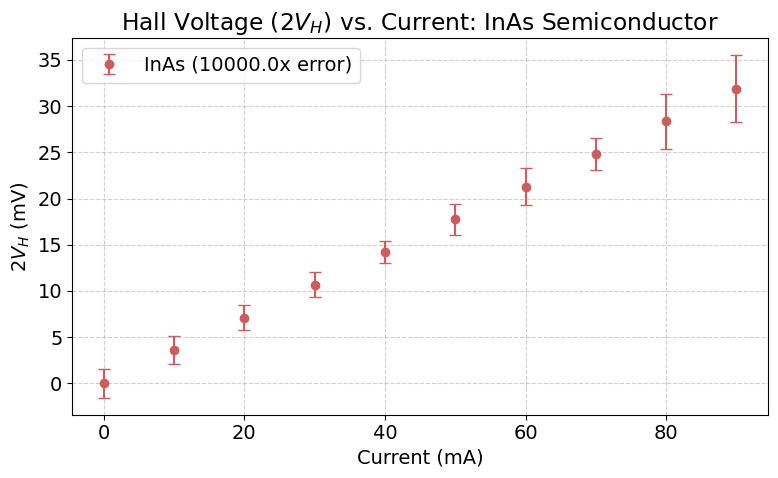

In [39]:
# Plot data for InAs probe

SCALE_FACTOR = 1e4

plt.figure(figsize=(8, 5))
plt.errorbar(current_inas, inas_y, yerr=inas_yerr * SCALE_FACTOR, fmt='o', capsize=4, label=f'InAs ({SCALE_FACTOR}x error)', color='indianred')

plt.title('Hall Voltage ($2V_H$) vs. Current: InAs Semiconductor')
plt.xlabel('Current (mA)')
plt.ylabel('$2V_H$ (mV)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

## Fit the data to extract the slope of $2V_H/I_x$

Use LMfit.  See the examples.

In [40]:
# Set  up the Model  This cell does the import and model instance creation

# Import the Linear model.
# You only do this once in a notebook
from lmfit.models import LinearModel

# create an instance of the model
# You only need to do this once
line = LinearModel()

ALUMINUM FIT REPORT
[[Model]]
    Model(linear)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 7
    # data points      = 9
    # variables        = 2
    chi-square         = 8.55623559
    reduced chi-square = 1.22231937
    Akaike info crit   = 3.54492174
    Bayesian info crit = 3.93937090
    R-squared          = 0.99537014
[[Variables]]
    slope:      3.0446e-05 +/- 6.0465e-07 (1.99%) (init = 3.042027e-05)
    intercept:  4.3922e-04 +/- 6.6939e-05 (15.24%) (init = 0.0004348649)
[[Correlations]] (unreported correlations are < 0.100)
    C(slope, intercept) = -0.7798


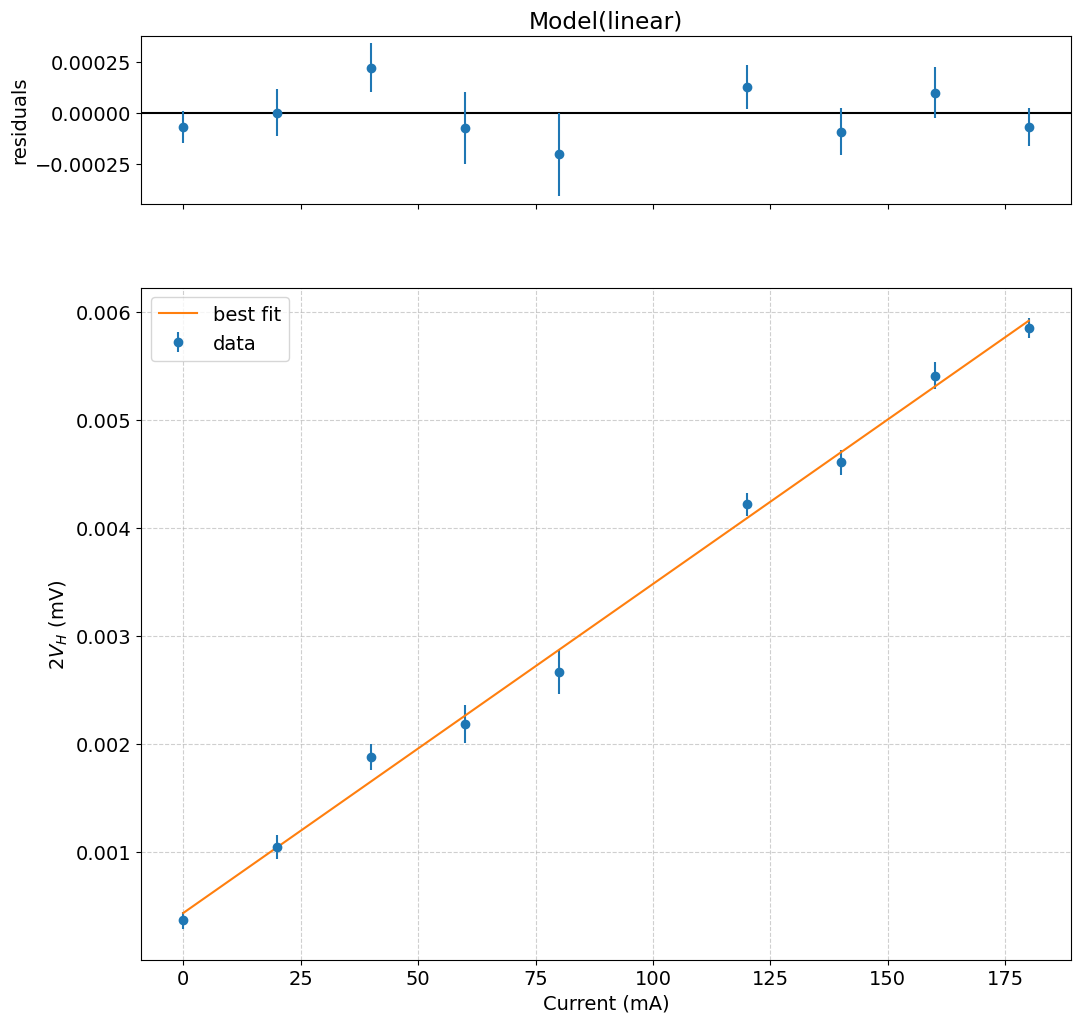

In [41]:
# Aluminum first
# Get starting parameters with the guess() method

# Fitting weights, 1 / uncertainty
al_weights = 1.0 / np.where(al_yerr == 0, 1e-9, al_yerr)

# Estimating initial intercept and slope based off data arrays
params = line.guess(al_y, x=current_al)

# Feeding weights into fitter.
Al_fit = line.fit(al_y, params, x=current_al, weights=al_weights)

# Plotting 
Al_fit.plot()

# Prints the results
print("="*40)
print("ALUMINUM FIT REPORT")
print("="*40)
print(Al_fit.fit_report()) # Displaying R-squared value, best fit slope and parameter uncertainties
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel('Current (mA)')
plt.ylabel('$2V_H$ (mV)');

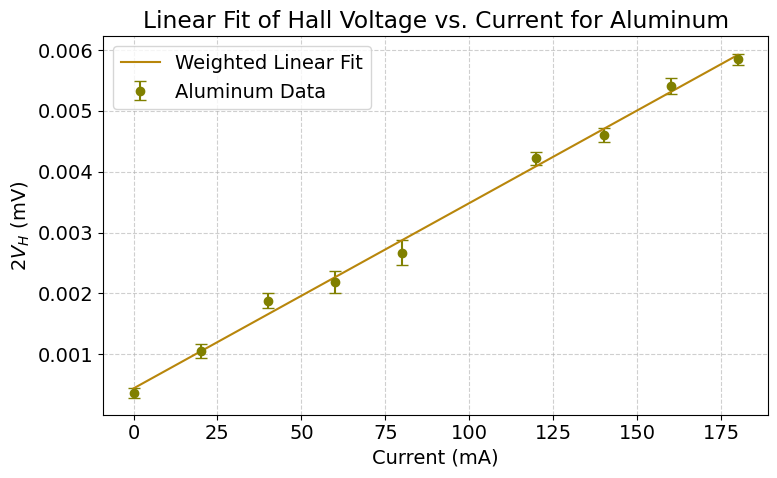

In [42]:
# Make a plot
plt.figure(figsize=(8, 5))
plt.errorbar(current_al, al_y, yerr=al_yerr, fmt='o', capsize=4, label='Aluminum Data', color='olive')
plt.plot(current_al, Al_fit.best_fit, '-', label='Weighted Linear Fit', color='darkgoldenrod') # Linear fit from best-fit values calculated by lmfit

plt.title('Linear Fit of Hall Voltage vs. Current for Aluminum')
plt.xlabel('Current (mA)')
plt.ylabel('$2V_H$ (mV)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### Extract the slope with uncertainty from the fit parameters


In [43]:
# See the examples for how to access fit parameters from the fit results

# Grabbing raw slope values and the uncertainty from the fit (mV/mA)
slope_val = Al_fit.params['slope'].value
slope_err = Al_fit.params['slope'].stderr

# Creating uncertainty object
Al_slope = ufloat(slope_val, slope_err)

# When you have the uncertainty object Al_slope, you can print it out this way:
print('2VH/Ix for aluminum = {:.2uP} V/A'.format(Al_slope))

2VH/Ix for aluminum = (3.045±0.060)×10⁻⁵ V/A


### Calculate the Hall coefficient

The Hall coefficient $R_H$ is related to the measurements by

$$V_H = -R_H\frac{I_xB_z}{t}$$ 

where $t$ is the thichness of the sample strip.  From the linefit, we have the slope $m = 2V_H/I_x$  so

$$R_H = -m\frac{t}{2B_z}$$

In the instructions there is a list of probe parameters.  Use these to calculate the Hall coefficient and its statistical uncertainty.


In [44]:
# For Al, from Table 1, create uncertainty object for thickness

# Magnetic field value 
B_z = ufloat(0.133467, 0.002041) 

# For Al, from Table 1, create uncertainty object for thickness
t_Al = ufloat(2.34e-7, 0.17e-7)

# Then calculate the Hall coefficient using your uncertainty object for B and the thickness.
# R_H = -m * t / (2 * B_z)
RH_Al = -Al_slope * t_Al / (2 * B_z)

print('The Hall coefficient for the aluminum probe is {:.2uP} m^3/A-s'.format(RH_Al))

The Hall coefficient for the aluminum probe is (-2.67±0.21)×10⁻¹¹ m^3/A-s


In [45]:
# Here is an example of how to extract the relative contributions of the different
# quantities that go into the calculation.  See how the "tags" are used.

# Tagging components to identify in the error analysis printout 
Al_slope.tag = 'Slope'
t_Al.tag = 'Thickness'
B_z.tag = 'B-Field'

print('Percent contribution to statistical uncertainty:')
for (var,error) in RH_Al.error_components().items():
    print('{:>6s}: {:.3%}'.format(var.tag,(error/RH_Al.s)**2))

Percent contribution to statistical uncertainty:
B-Field: 3.959%
Thickness: 89.363%
 Slope: 6.678%


## Repeat above for other samples

### Gold probe

Comments are minimal.

GOLD FIT REPORT
[[Model]]
    Model(linear)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 7
    # data points      = 10
    # variables        = 2
    chi-square         = 240.851929
    reduced chi-square = 30.1064911
    Akaike info crit   = 35.8159725
    Bayesian info crit = 36.4211427
    R-squared          = 0.99036867
[[Variables]]
    slope:      1.0857e-04 +/- 2.8859e-06 (2.66%) (init = 0.0001057212)
    intercept:  5.9188e-04 +/- 3.2659e-04 (55.18%) (init = 0.0009190909)
[[Correlations]] (unreported correlations are < 0.100)
    C(slope, intercept) = -0.8349


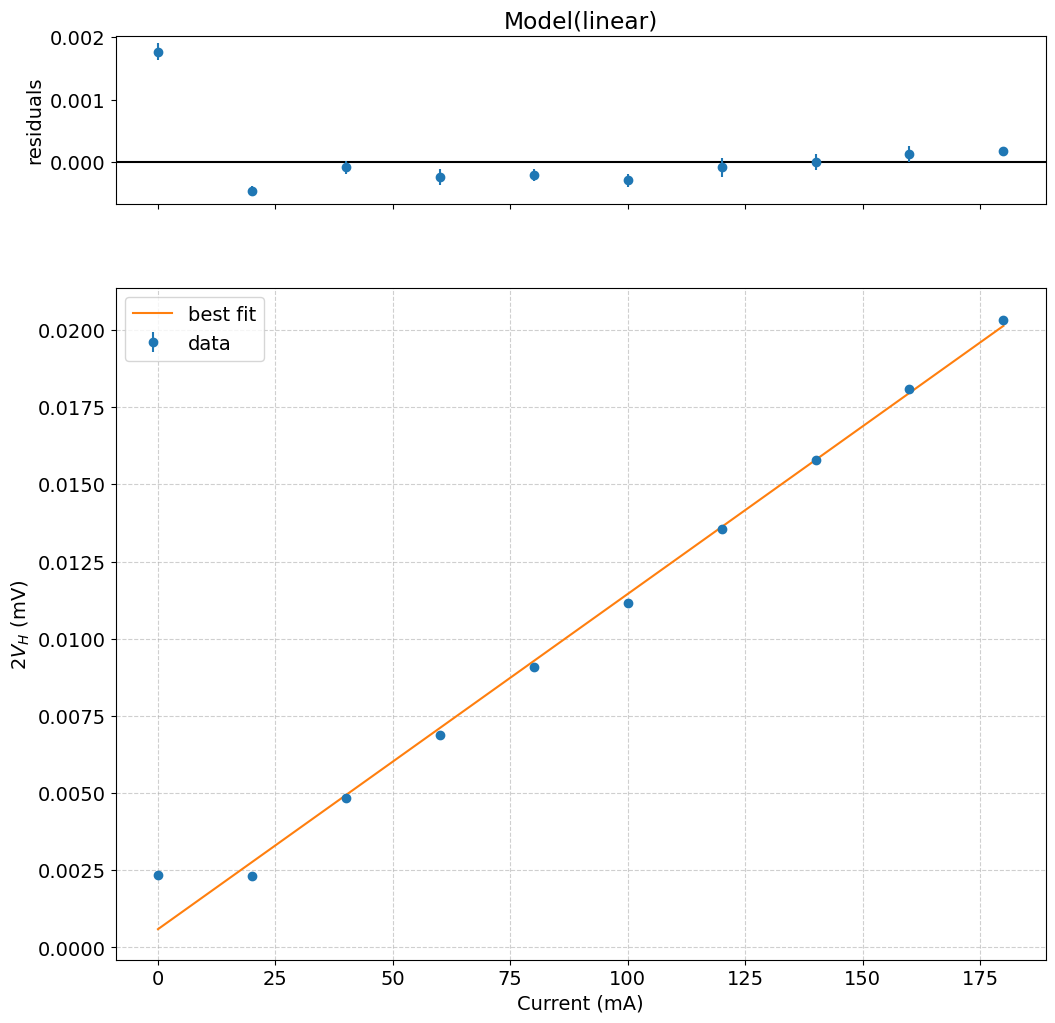

In [46]:
## GOLD PROBE ##

# Gold
#
# Run the fit

# Fitting weights, 1 / uncertainty
au_weights = 1.0 / np.where(au_yerr == 0, 1e-9, au_yerr)

# Estimating initial intercept and slope based off data arrays
params_au = line.guess(au_y, x=current_au)
Au_fit = line.fit(au_y, params_au, x=current_au, weights=au_weights)

Au_fit.plot()

# Print the results
print("="*40)
print("GOLD FIT REPORT")
print("="*40)
print(Au_fit.fit_report()) # Displaying R-squared value, best fit slope and parameter uncertainties
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel('Current (mA)')
plt.ylabel('$2V_H$ (mV)');

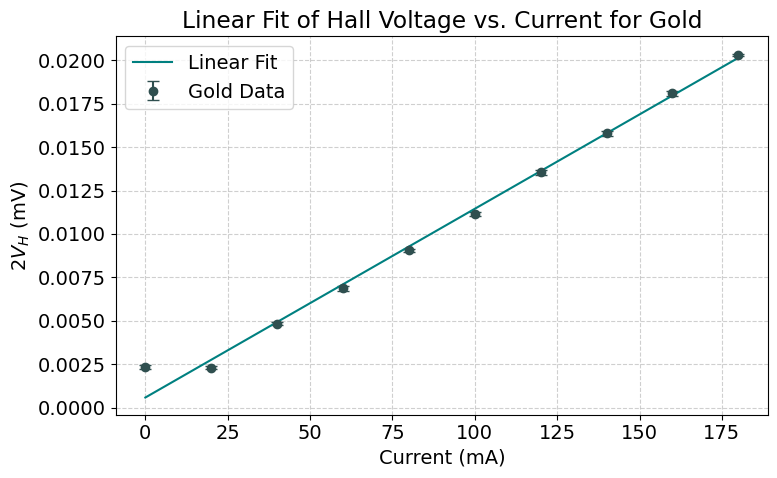

In [47]:
# Make a plot
plt.figure(figsize=(8, 5))
plt.errorbar(current_au, au_y, yerr=au_yerr, fmt='o', capsize=4, label='Gold Data', color='darkslategrey')
plt.plot(current_au, Au_fit.best_fit, '-', label='Linear Fit', color='teal')
plt.title('Linear Fit of Hall Voltage vs. Current for Gold')
plt.xlabel('Current (mA)')
plt.ylabel('$2V_H$ (mV)')  
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

In [48]:
# Get the slope, make an uncertainty object, and print it out

# Converting slope from V/mA to V/A
Au_slope_val = Au_fit.params['slope'].value 
Au_slope_err = Au_fit.params['slope'].stderr
Au_slope = ufloat(Au_slope_val, Au_slope_err)

print('2VH/Ix for gold = {:.2uP} V/A'.format(Au_slope))

2VH/Ix for gold = 0.0001086±0.0000029 V/A


In [49]:
# Get the thickness, calculate the Hall coefficient and print out the relative error contributions.

t_Au = ufloat(1.37e-7, 0.16e-7)

# R_H = -m * t / (2 * B_z)
RH_Au = -Au_slope * t_Au / (2 * B_z)

# tagging components
Au_slope.tag = 'Slope'
t_Au.tag = 'Thickness'
B_z.tag = 'B-Field'

print('The Hall coefficient for the gold probe is {:.2uP} m^3/A-s'.format(RH_Au))

print('\nPercent contribution to statistical uncertainty (Gold):')
for (var, error) in RH_Au.error_components().items():
    print('{:>10s}: {:.3%}'.format(var.tag, (error / RH_Au.s)**2))

The Hall coefficient for the gold probe is (-5.57±0.67)×10⁻¹¹ m^3/A-s

Percent contribution to statistical uncertainty (Gold):
   B-Field: 1.604%
 Thickness: 93.550%
     Slope: 4.846%


### InAs probe

InAs FIT REPORT
[[Model]]
    Model(linear)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 7
    # data points      = 10
    # variables        = 2
    chi-square         = 50101.9522
    reduced chi-square = 6262.74403
    Akaike info crit   = 89.1923016
    Bayesian info crit = 89.7974718
    R-squared          = 0.99999772
[[Variables]]
    slope:      0.35413791 +/- 1.7430e-04 (0.05%) (init = 0.3539607)
    intercept:  0.03060533 +/- 0.00733604 (23.97%) (init = 0.03442109)
[[Correlations]] (unreported correlations are < 0.100)
    C(slope, intercept) = -0.8311


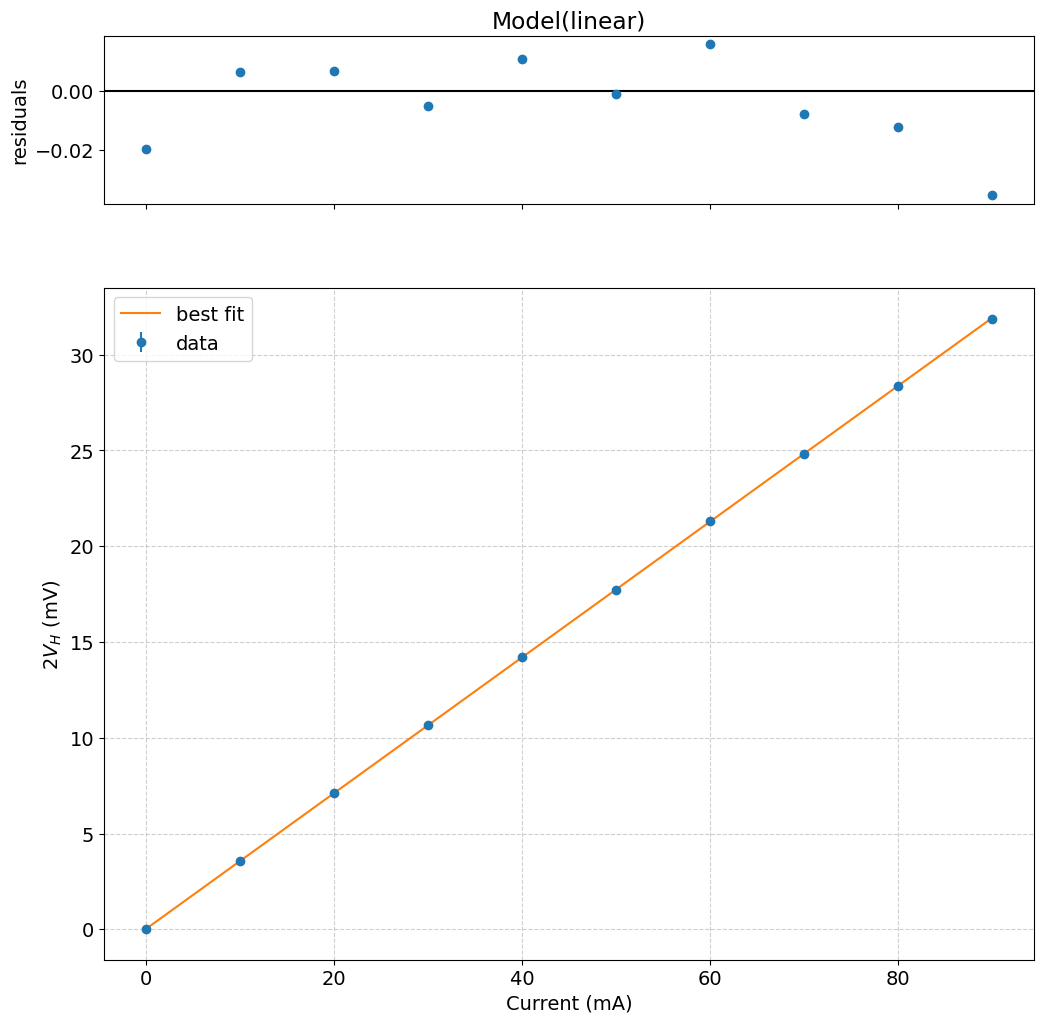

In [50]:
# Indium-Arsenide 
#
# Run the fit

inas_weights = 1.0 / np.where(inas_yerr == 0, 1e-9, inas_yerr)

params_inas = line.guess(inas_y, x=current_inas)
InAs_fit = line.fit(inas_y, params_inas, x=current_inas, weights=inas_weights)

InAs_fit.plot()

# Print the results
print("="*40)
print("InAs FIT REPORT")
print("="*40)
print(InAs_fit.fit_report()) # Displaying R-squared value, best fit slope and parameter uncertainties
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel('Current (mA)')
plt.ylabel('$2V_H$ (mV)');

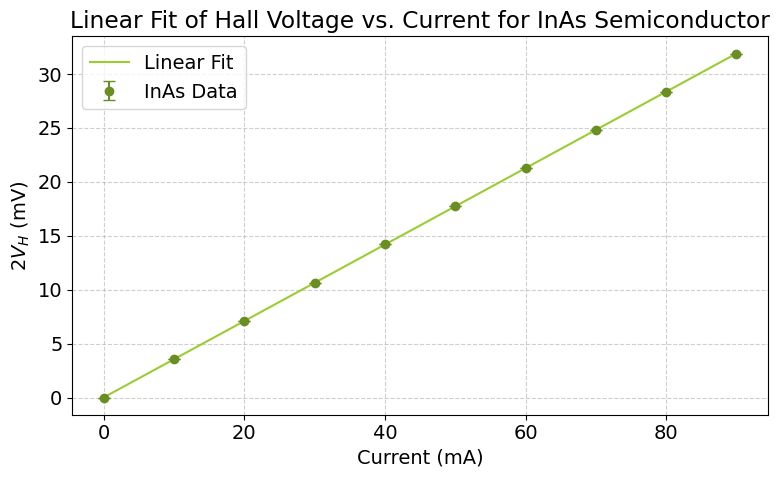

In [51]:
# Make a plot
plt.figure(figsize=(8, 5))
plt.errorbar(current_inas, inas_y, yerr=inas_yerr, fmt='o', capsize=4, label='InAs Data', color='olivedrab')
plt.plot(current_inas, InAs_fit.best_fit, '-', label='Linear Fit', color='yellowgreen')
plt.title('Linear Fit of Hall Voltage vs. Current for InAs Semiconductor')
plt.xlabel('Current (mA)')
plt.ylabel('$2V_H$ (mV)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

In [52]:
# Get the slope, make an uncertainty object, and print it out

# Converting slope from V/mA to V/A
InAs_slope_val = InAs_fit.params['slope'].value 
InAs_slope_err = InAs_fit.params['slope'].stderr 
InAs_slope = ufloat(InAs_slope_val, InAs_slope_err)

print('2VH/Ix for InAs = {:.2uP} V/A'.format(InAs_slope))

2VH/Ix for InAs = 0.35414±0.00017 V/A


In [53]:
# Get the thickness, calculate the Hall coefficient and print out the relative error contributions.
t_InAs = ufloat(1.26e-4, 0.02e-4)

# R_H = -m * t / (2 * B_z)
RH_InAs = -InAs_slope * t_InAs / (2 * B_z)

# Tagging components
InAs_slope.tag = 'Slope'
t_InAs.tag = 'Thickness'
B_z.tag = 'B-Field'

print('The Hall coefficient for the InAs probe is {:.2uP} m^3/A-s'.format(RH_InAs))

print('\nPercent contribution to statistical uncertainty (InAs):')
for (var, error) in RH_InAs.error_components().items():
    print('{:>10s}: {:.3%}'.format(var.tag, (error / RH_InAs.s)**2))

The Hall coefficient for the InAs probe is -0.0001672±0.0000037 m^3/A-s

Percent contribution to statistical uncertainty (InAs):
   B-Field: 48.113%
 Thickness: 51.837%
     Slope: 0.050%


## Conductivity calculations

From equation (13) in the instructions

$$\sigma = \frac{\ell}{Rwt}$$

We use the data in table 1.

In [54]:
# Create uncertainty objects from the data in Table 1 for each sample

# Note: length and width are in mm, converting to meters (* 1e-3)

# Gold:
l_Au = ufloat(30.5, 0.05) * 1e-3    # m
w_Au = ufloat(12.7, 0.05) * 1e-3    # m
t_Au = ufloat(1.37e-7, 0.16e-7)     # m
R_Au = ufloat(0.770, 0.006)         # Ohms

# Aluminum:
l_Al = ufloat(30.5, 0.05) * 1e-3    # m
w_Al = ufloat(12.7, 0.05) * 1e-3    # m
t_Al = ufloat(2.34e-7, 0.17e-7)     # m
R_Al = ufloat(0.872, 0.018)         # Ohms

# InAs:
l_InAs = ufloat(1.542, 0.005) * 1e-3 # m
w_InAs = ufloat(0.692, 0.004) * 1e-3 # m
t_InAs = ufloat(1.26e-4, 0.02e-4)    # m
R_InAs = ufloat(1.3, 0.3)            # Ohms

# Calculate the conductivity for each sample from the above
#sigma = l / (R * w * t)
sigma_Au = l_Au / (R_Au * w_Au * t_Au)
sigma_Al = l_Al / (R_Al * w_Al * t_Al)
sigma_InAs = l_InAs / (R_InAs * w_InAs * t_InAs)

# Print the results WITH UNITS for each sample
print('Conductivity for Gold (Au)       = {:.2uP} S/m'.format(sigma_Au))
print('Conductivity for Aluminum (Al)   = {:.2uP} S/m'.format(sigma_Al))
print('Conductivity for InAs            = {:.2uP} S/m'.format(sigma_InAs))

Conductivity for Gold (Au)       = (2.28±0.27)×10⁷ S/m
Conductivity for Aluminum (Al)   = (1.177±0.089)×10⁷ S/m
Conductivity for InAs            = (1.36±0.31)×10⁴ S/m


### Calculate mobility for InAs probe

(Metal probe "mobility" is optional, because it does not mean very much.) From exercise 4

$$\mu = \sigma R_H$$.

In [55]:
# Calculate the Carrier density of the InAs probe from the Hall coefficient and charge of the electron

# Scientific constants are in SciPy
import scipy.constants as const 

# Calculate the carrier density and print it WITH UNITS

# Carrier density n = 1 / (|RH| * e)
n_InAs = 1 / (abs(RH_InAs) * const.e)

# Mobility calculation, mu = sigma * |RH|
mu_InAs = (sigma_InAs * abs(RH_InAs)) 

print(' InAs Semiconductor Probe ')
print('Carrier Density (n) = {:.2uP} carriers/m^3'.format(n_InAs))
print('Carrier Mobility (μ) = {:.2uP} m^2/(V·s)'.format(mu_InAs))
print()

 InAs Semiconductor Probe 
Carrier Density (n) = (3.734±0.082)×10²² carriers/m^3
Carrier Mobility (μ) = 2.27±0.53 m^2/(V·s)



In [56]:
# Optional: Mobility for metals, just because we can

# Mobilities for Al and Au
print(' Metal Probes ')

# Au
n_Au = 1 / (abs(RH_Au) * const.e)
mu_Au = sigma_Au * abs(RH_Au)
print('Gold Carrier Density (n) = {:.2uP} carriers/m^3'.format(n_Au))
print('Gold Carrier Mobility (μ) = {:.2uP} m^2/(V·s)'.format(mu_Au))

# Al
n_Al = 1 / (abs(RH_Al) * const.e)
mu_Al = sigma_Al * abs(RH_Al)
print('Aluminum Carrier Density (n) = {:.2uP} carriers/m^3'.format(n_Al))
print('Aluminum Carrier Mobility (μ) = {:.2uP} m^2/(V·s)'.format(mu_Al))

 Metal Probes 
Gold Carrier Density (n) = (1.12±0.14)×10²⁹ carriers/m^3
Gold Carrier Mobility (μ) = 0.00127±0.00021 m^2/(V·s)
Aluminum Carrier Density (n) = (2.34±0.18)×10²⁹ carriers/m^3
Aluminum Carrier Mobility (μ) = 0.000314±0.000034 m^2/(V·s)
